<a href="https://colab.research.google.com/github/data-mkdozistats/weather-analysis-project/blob/main/Copy_of_Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Analysis of Temperature
Mean = 30.2
Median = 30.0
Mode = 29
Range = 9
Quartile Deviation = 1.88
Standard Deviation = 2.37
Skewness = 0.22 - Positively Skewed
Kurtosis = -0.85 - Platykurtic


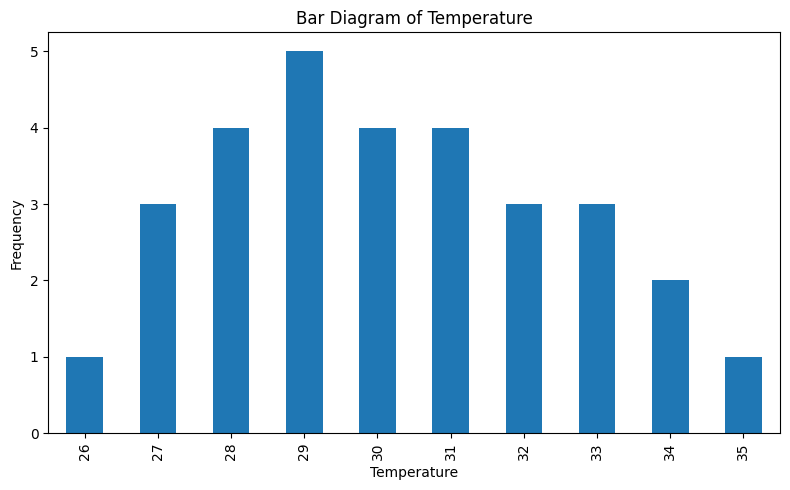

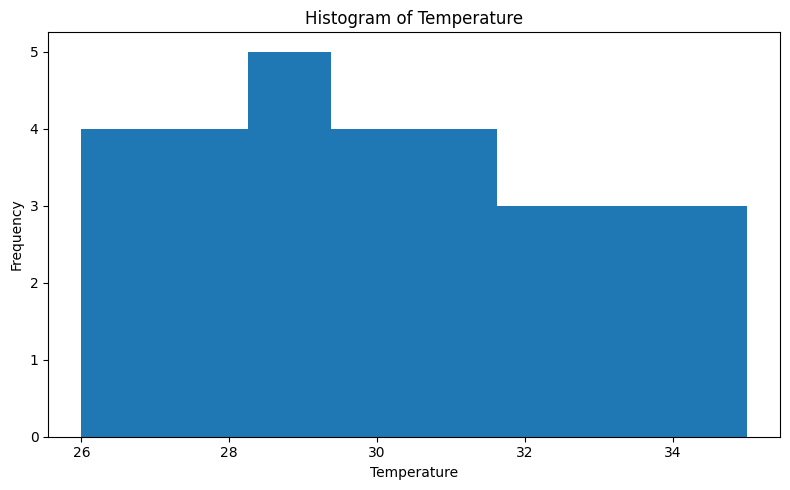

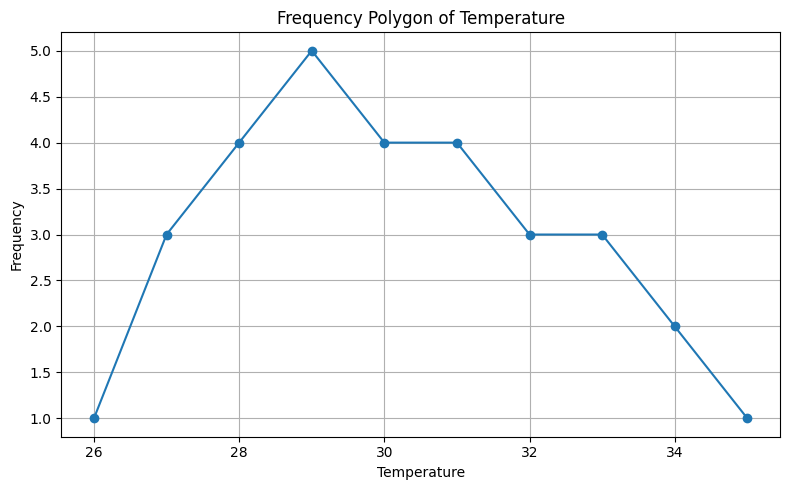


Analysis of Humidity
Mean = 64.33
Median = 64.5
Mode = 58
Range = 28
Quartile Deviation = 5.25
Standard Deviation = 7.25
Skewness = -0.04 - Negatively Skewed
Kurtosis = -0.73 - Platykurtic


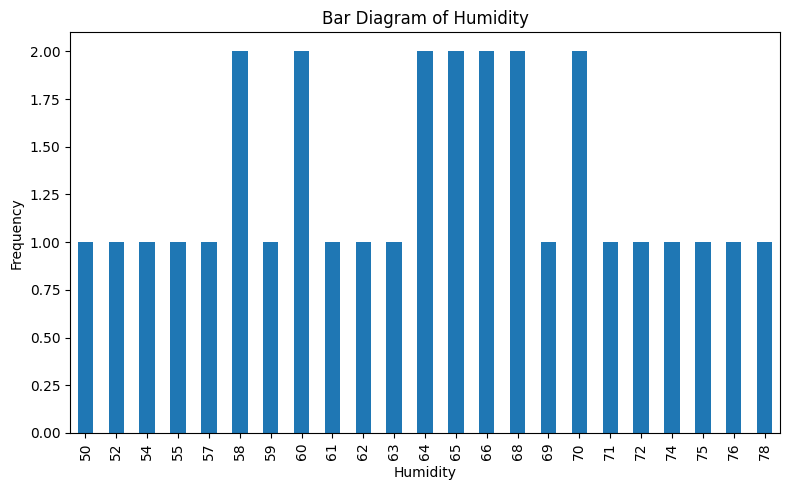

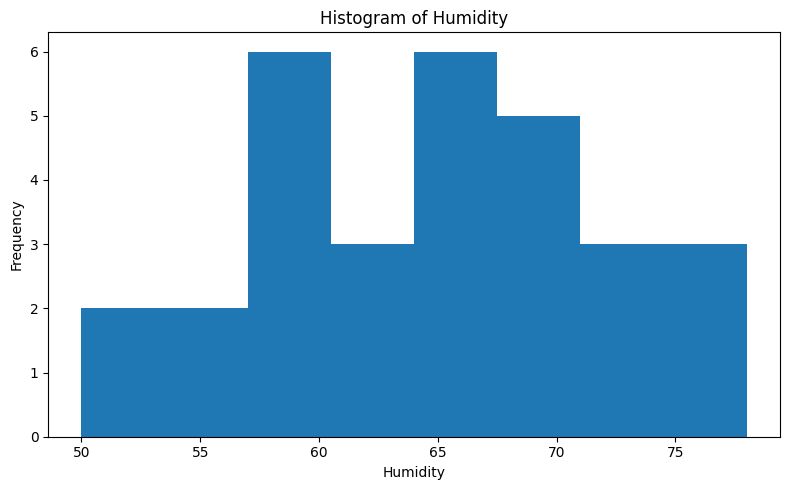

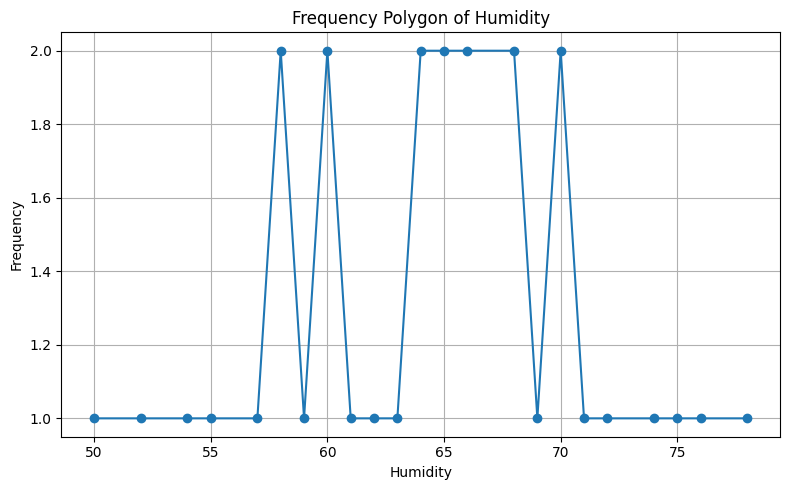


Analysis of Rainfall
Mean = 2.97
Median = 0.5
Mode = 0
Range = 12
Quartile Deviation = 2.88
Standard Deviation = 3.96
Skewness = 1.0 - Positively Skewed
Kurtosis = -0.47 - Platykurtic


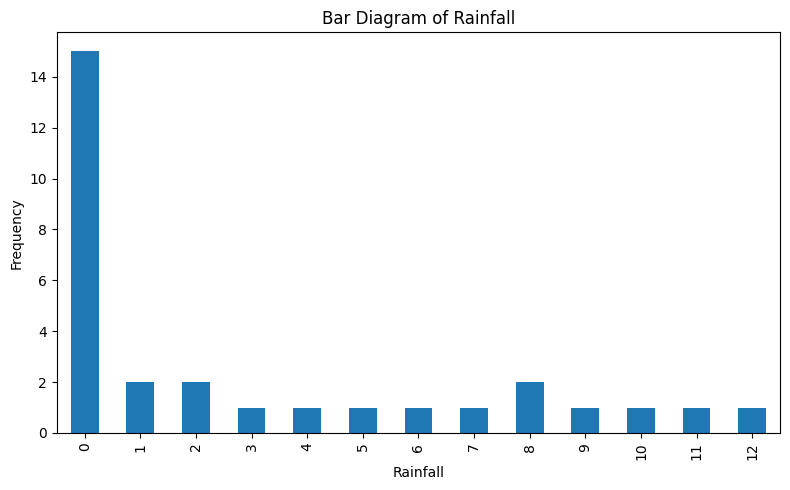

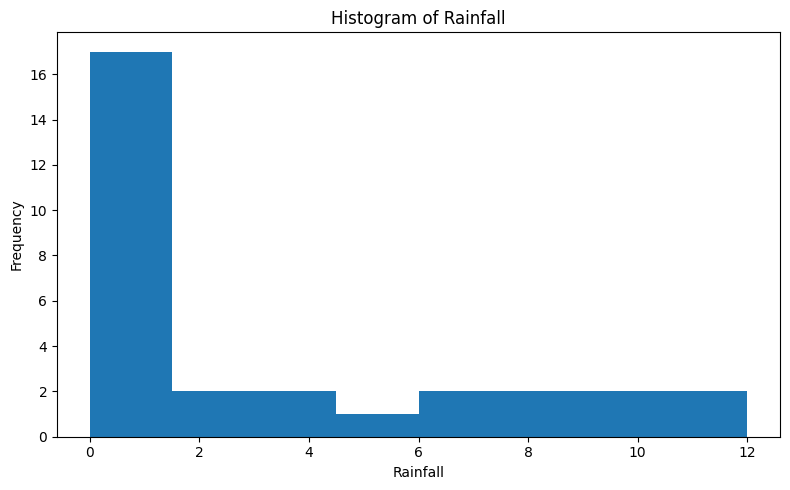

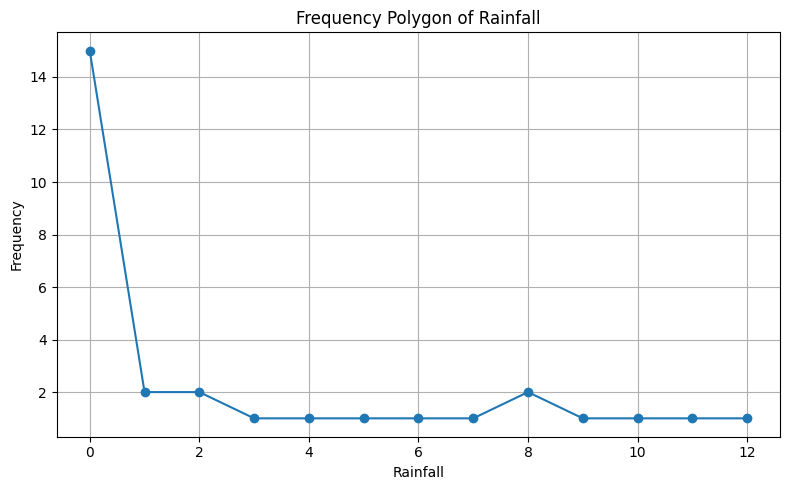


Analysis of WindSpeed
Mean = 11.1
Median = 10.5
Mode = 10
Range = 15
Quartile Deviation = 2.75
Standard Deviation = 3.75
Skewness = 0.52 - Positively Skewed
Kurtosis = -0.38 - Platykurtic


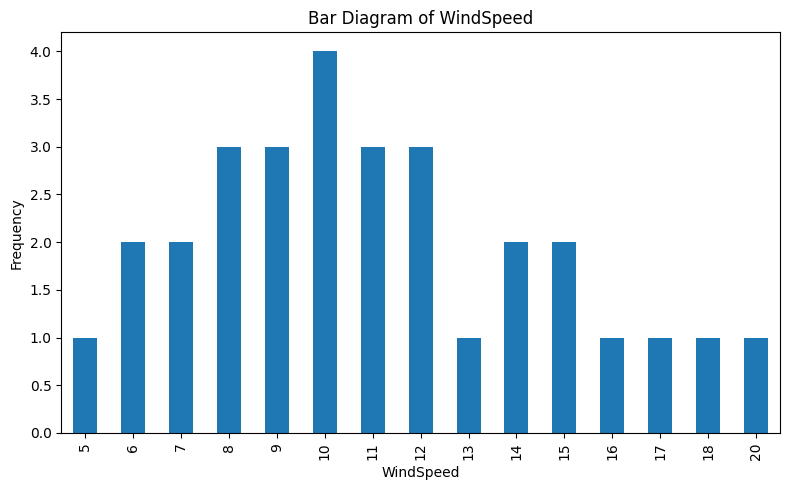

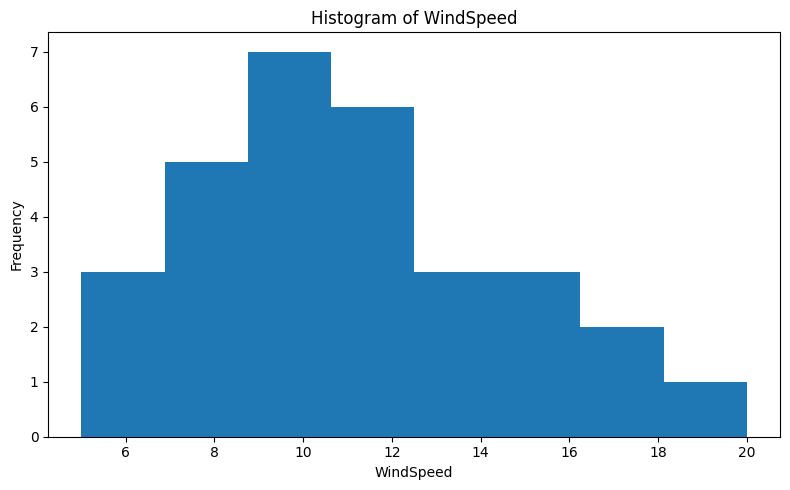

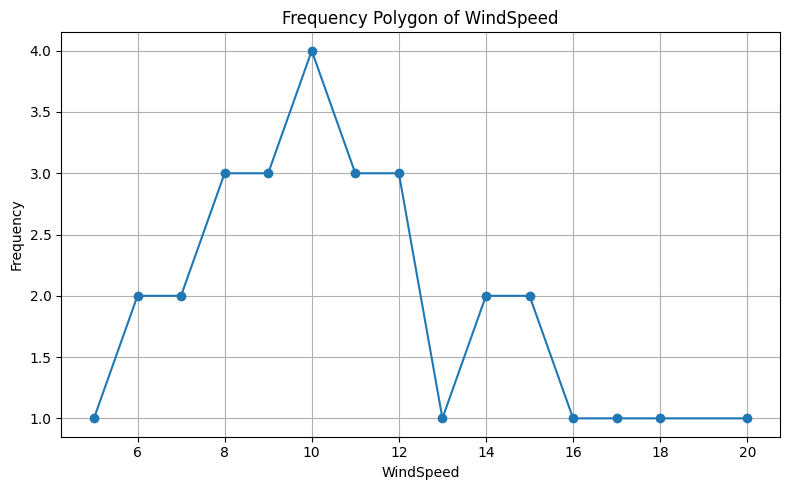

In [ ]:
import pandas as pd
from io import StringIO
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

# Dataset
data = """
Date,Temperature,Humidity,Rainfall,WindSpeed
2026-01-01,28,65,0,12
2026-01-02,30,60,0,10
2026-01-03,27,70,5,15
2026-01-04,26,75,10,18
2026-01-05,29,68,0,11
2026-01-06,31,62,0,9
2026-01-07,32,58,0,8
2026-01-08,30,64,2,12
2026-01-09,28,72,8,16
2026-01-10,27,78,12,20
2026-01-11,29,66,0,10
2026-01-12,33,55,0,7
2026-01-13,34,52,0,6
2026-01-14,32,60,1,9
2026-01-15,31,63,3,11
2026-01-16,28,70,7,14
2026-01-17,27,76,11,17
2026-01-18,29,68,0,10
2026-01-19,30,65,0,9
2026-01-20,32,59,0,8
2026-01-21,33,57,0,7
2026-01-22,31,61,2,10
2026-01-23,29,69,6,13
2026-01-24,28,74,9,15
2026-01-25,30,66,0,11
2026-01-26,34,54,0,6
2026-01-27,35,50,0,5
2026-01-28,33,58,1,8
2026-01-29,31,64,4,12
2026-01-30,29,71,8,14
"""

# Create DataFrame
df = pd.read_csv(StringIO(data))

# Variables to Analyze
variables = ["Temperature", "Humidity", "Rainfall", "WindSpeed"]

for col in variables:

    print("\n" + "="*50)
    print(f"Analysis of {col}")
    print("="*50)

    # Measures of Central Tendency
    mean = df[col].mean()
    median = df[col].median()
    mode = df[col].mode()[0]

    # Measures of Dispersion
    data_range = df[col].max() - df[col].min()

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    quartile_deviation = (q3 - q1) / 2

    std_dev = df[col].std()

    # Skewness and Kurtosis
    skewness = skew(df[col])
    kurt = kurtosis(df[col])

    # Interpretation of Skewness
    if skewness > 0:
        skew_type = "Positively Skewed"
    elif skewness < 0:
        skew_type = "Negatively Skewed"
    else:
        skew_type = "Symmetrical"

    # Interpretation of Kurtosis
    if kurt > 0:
        kurt_type = "Leptokurtic"
    elif kurt < 0:
        kurt_type = "Platykurtic"
    else:
        kurt_type = "Mesokurtic"

    # Print Results
    print("Mean =", round(mean, 2))
    print("Median =", median)
    print("Mode =", mode)
    print("Range =", data_range)
    print("Quartile Deviation =", round(quartile_deviation, 2))
    print("Standard Deviation =", round(std_dev, 2))
    print("Skewness =", round(skewness, 2), "-", skew_type)
    print("Kurtosis =", round(kurt, 2), "-", kurt_type)

    # Frequency Table
    freq_table = df[col].value_counts().sort_index()

    # Bar Diagram
    plt.figure(figsize=(8, 5))
    freq_table.plot(kind='bar')
    plt.title(f'Bar Diagram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

    # Histogram
    plt.figure(figsize=(8, 5))
    plt.hist(df[col], bins=8)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

    # Frequency Polygon
    plt.figure(figsize=(8, 5))
    plt.plot(freq_table.index, freq_table.values, marker='o')
    plt.title(f'Frequency Polygon of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.tight_layout()
    plt.show()